# Lahore Air Quality Index (AQI) - Exploratory Data Analysis (EDA)

This notebook provides an in-depth exploratory analysis of 2 years of hourly atmospheric air pollution data for Lahore, Pakistan.

### Feature Inventory:
- **Target Variable:** `aqi_target` (OpenWeather AQI Scale 1-5: 1=Good, 2=Fair, 3=Moderate, 4=Poor/Unhealthy, 5=Hazardous)
- **Atmospheric Pollutants:** `pm2_5`, `pm10`, `no2`, `co`, `o3` (ug/m3)
- **Engineered Features:** `pm_ratio` (PM2.5/PM10) and `aqi_change_rate` (Delta AQI / Delta t)
- **Temporal Dimensions:** `hour`, `day`, `month`, `day_of_week`


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load historical dataset
DATA_PATH = '../data/historical_aqi_features.csv'
df = pd.read_csv(DATA_PATH)

# Standardize timestamp
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
elif 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])

# Target column identifier
target_col = 'aqi_target' if 'aqi_target' in df.columns else 'aqi'
print(f'Target column identified: {target_col}')
df.head()


Target column identified: aqi_target


,timestamp,hour,day,month,day_of_week,aqi_target,co,no2,o3,pm2_5,pm10,aqi_change_rate,pm_ratio
0,2024-08-17 14:00:00,14,17,8,5,2.0,841.14,12.85,72.24,18.76,20.02,0.0,0.9371
1,2024-08-17 15:00:00,15,17,8,5,2.0,867.84,17.65,73.67,23.12,24.44,0.0,0.9460
2,2024-08-17 16:00:00,16,17,8,5,3.0,947.95,22.96,68.66,29.02,30.48,1.0,0.9521
3,2024-08-17 17:00:00,17,17,8,5,3.0,1014.71,27.08,62.94,31.86,33.42,0.0,0.9533
4,2024-08-17 18:00:00,18,17,8,5,3.0,1308.44,47.30,33.97,37.11,40.20,0.0,0.9231


## 1. Dataset Shape, Types & Missing Value Audit
Examine column data types, row counts, and null distributions.

In [6]:
print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
print('\n--- Column Data Types & Non-Null Counts ---')
print(df.info())
print('\n--- Null Value Audit ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
df.describe().T


Dataset Shape: 16968 rows, 13 columns

--- Column Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 16968 entries, 0 to 16967
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        16968 non-null  datetime64[us]
 1   hour             16968 non-null  int64         
 2   day              16968 non-null  int64         
 3   month            16968 non-null  int64         
 4   day_of_week      16968 non-null  int64         
 5   aqi_target       16968 non-null  float64       
 6   co               16968 non-null  float64       
 7   no2              16968 non-null  float64       
 8   o3               16968 non-null  float64       
 9   pm2_5            16968 non-null  float64       
 10  pm10             16968 non-null  float64       
 11  aqi_change_rate  16968 non-null  float64       
 12  pm_ratio         16968 non-null  float64       
dtypes: datetime64[us](1

,count,mean,min,25%,50%,75%,max,std
timestamp,16968,2025-08-16 06:40:56.859971,2024-08-17 14:00:00,2025-02-11 07:45:00,2025-08-17 01:30:00,2026-02-11 19:15:00,2026-08-17 13:00:00,NaN
hour,16968.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922391
day,16968.0,15.817539,1.0,8.0,16.0,23.0,31.0,8.743488
month,16968.0,6.617751,1.0,4.0,7.0,10.0,12.0,3.449975
day_of_week,16968.0,3.014616,0.0,1.0,3.0,5.0,6.0,2.000595
aqi_target,16968.0,4.129204,1.0,3.0,4.0,5.0,5.0,0.944654
co,16968.0,1420.971866,111.06,410.56,685.895,1695.63,14953.61,1778.858401
no2,16968.0,28.045881,0.48,5.78,11.55,27.42,433.21,43.590124
o3,16968.0,70.783719,0.0,26.0075,62.23,109.1825,406.27,55.036051
pm2_5,16968.0,130.8742,0.0,38.51,68.62,166.64,1308.81,148.255652


## 2. Target Variable (AQI) Distribution
Analyze the class balance and frequency of OpenWeather AQI categories (1 to 5).

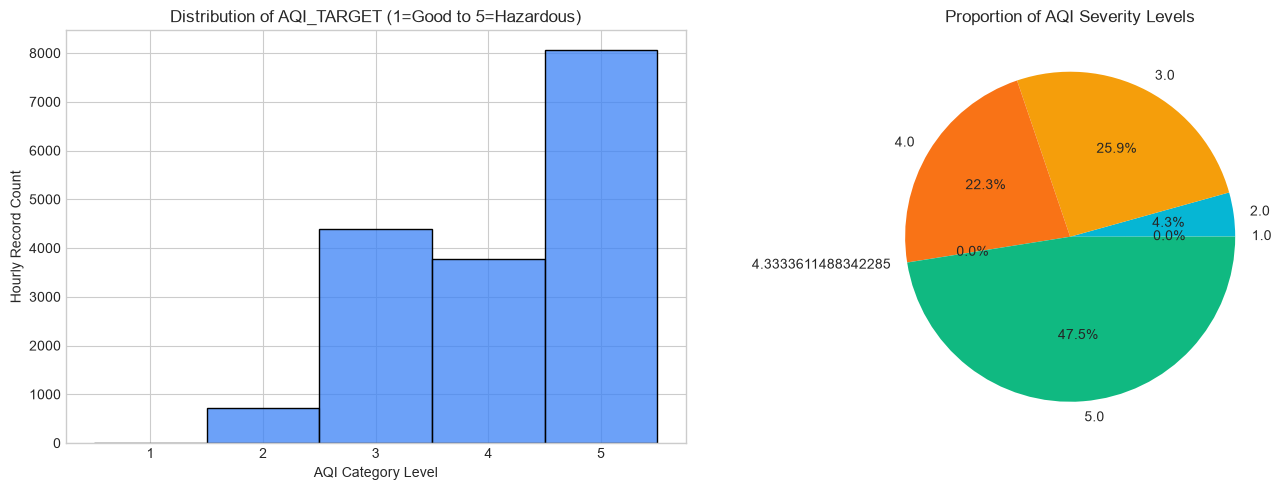

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target_col], discrete=True, kde=False, ax=ax[0], color='#3b82f6', edgecolor='black')
ax[0].set_title(f'Distribution of {target_col.upper()} (1=Good to 5=Hazardous)')
ax[0].set_xlabel('AQI Category Level')
ax[0].set_ylabel('Hourly Record Count')

colors = ['#10b981', '#06b6d4', '#f59e0b', '#f97316', '#ef4444']
df[target_col].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', ax=ax[1], colors=colors)
ax[1].set_title('Proportion of AQI Severity Levels')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()


## 3. Pollutant Concentration Distributions & Outlier Analysis
Examine key atmospheric pollutants (PM2.5, PM10, NO2, CO, O3, and PM Ratio).

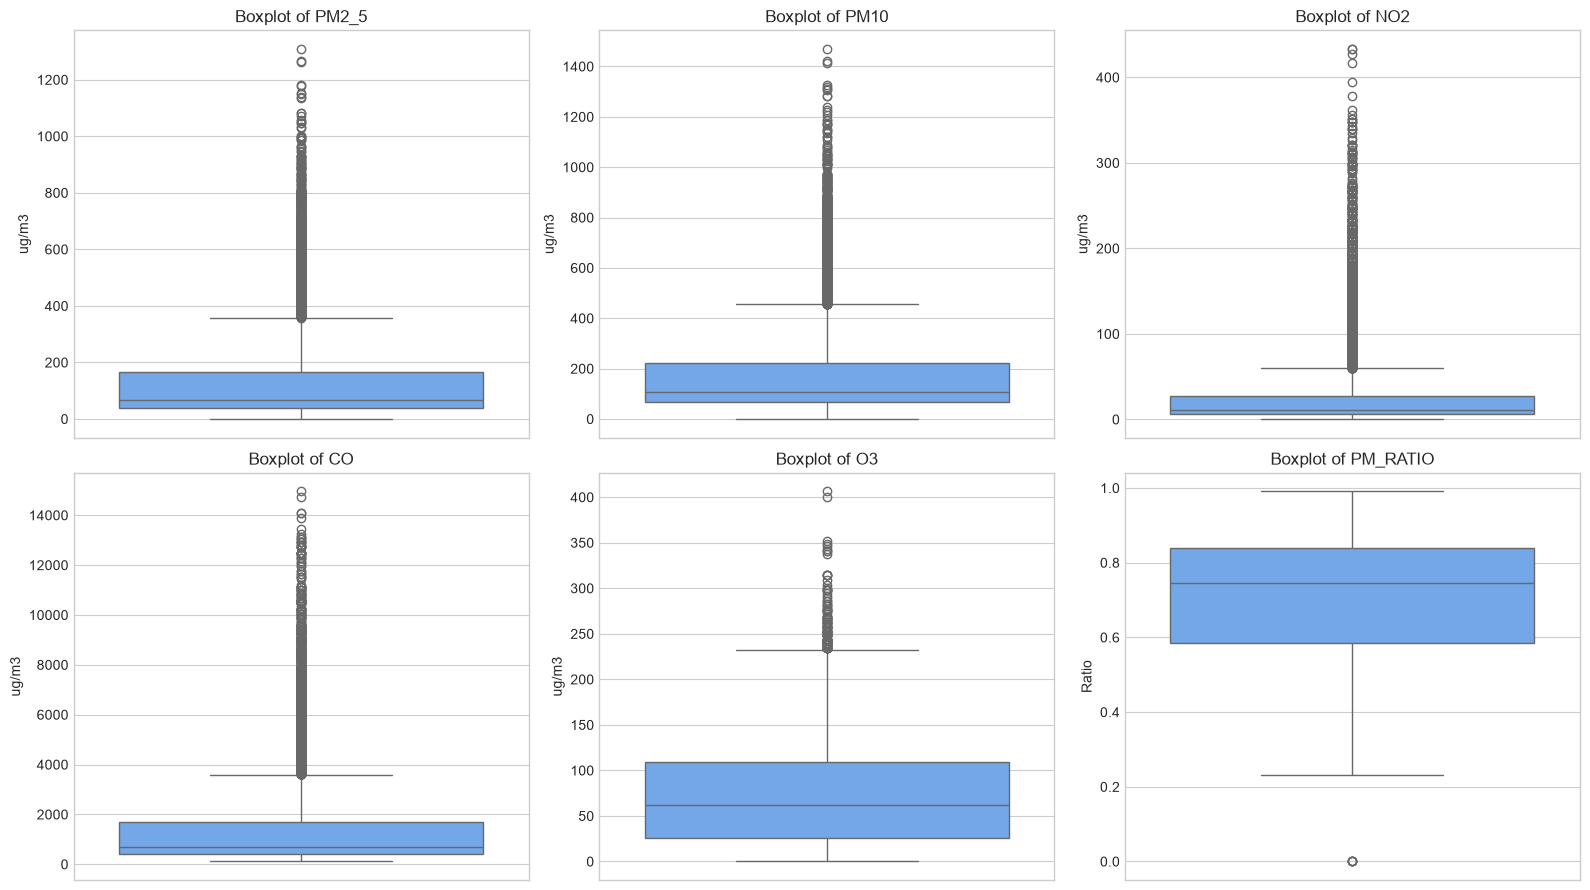

In [8]:
pollutant_cols = [c for c in ['pm2_5', 'pm10', 'no2', 'co', 'o3', 'pm_ratio'] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#60a5fa')
    axes[i].set_title(f'Boxplot of {col.upper()}')
    axes[i].set_ylabel('ug/m3' if 'ratio' not in col else 'Ratio')

plt.tight_layout()
plt.show()


## 4. Pearson Correlation Matrix & Feature Interdependencies
Evaluate multi-collinearity and correlations between atmospheric chemicals, temporal vectors, and AQI.

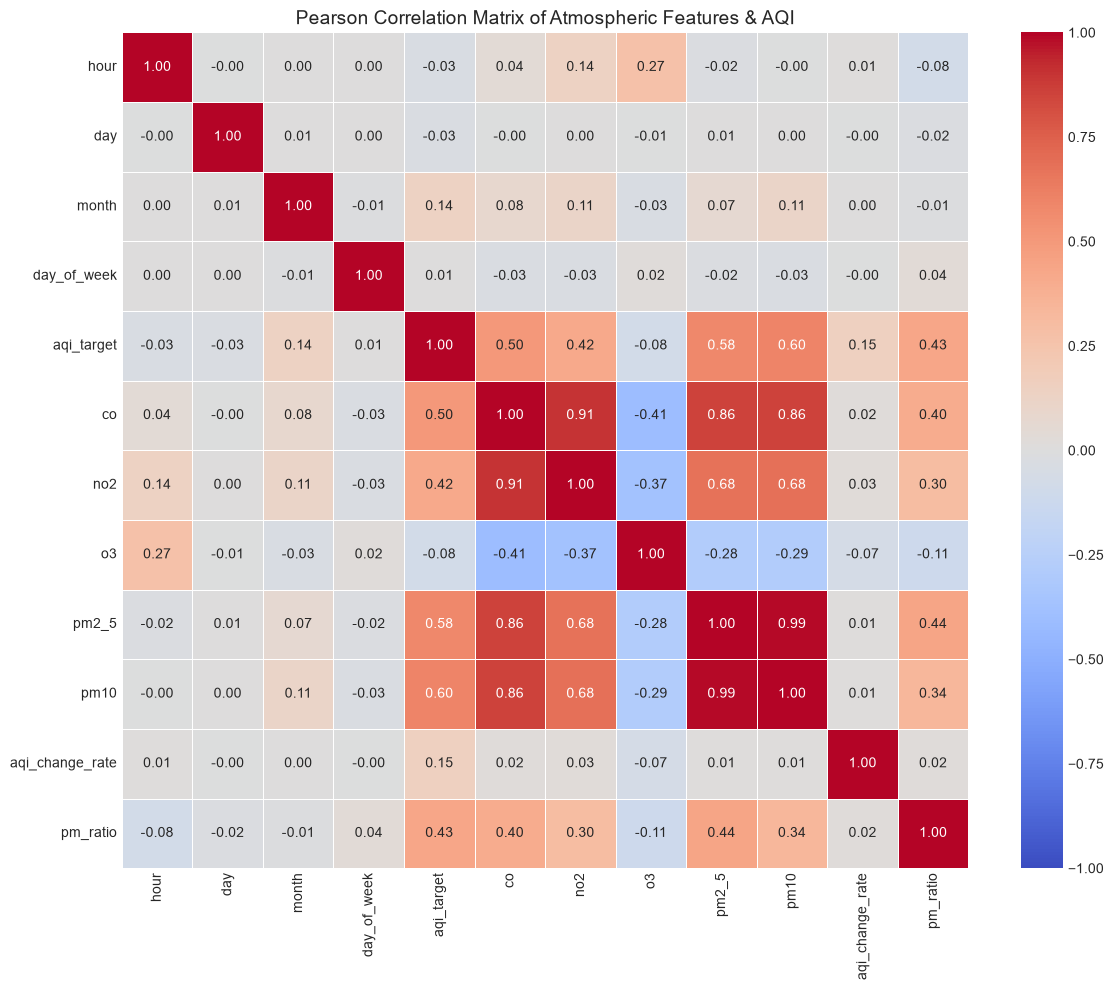

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation Matrix of Atmospheric Features & AQI', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Diurnal Smog Cycles (Hourly Inversion Patterns in Lahore)
Inspect daily inversion patterns where particulate matter spikes during night and early morning hours.

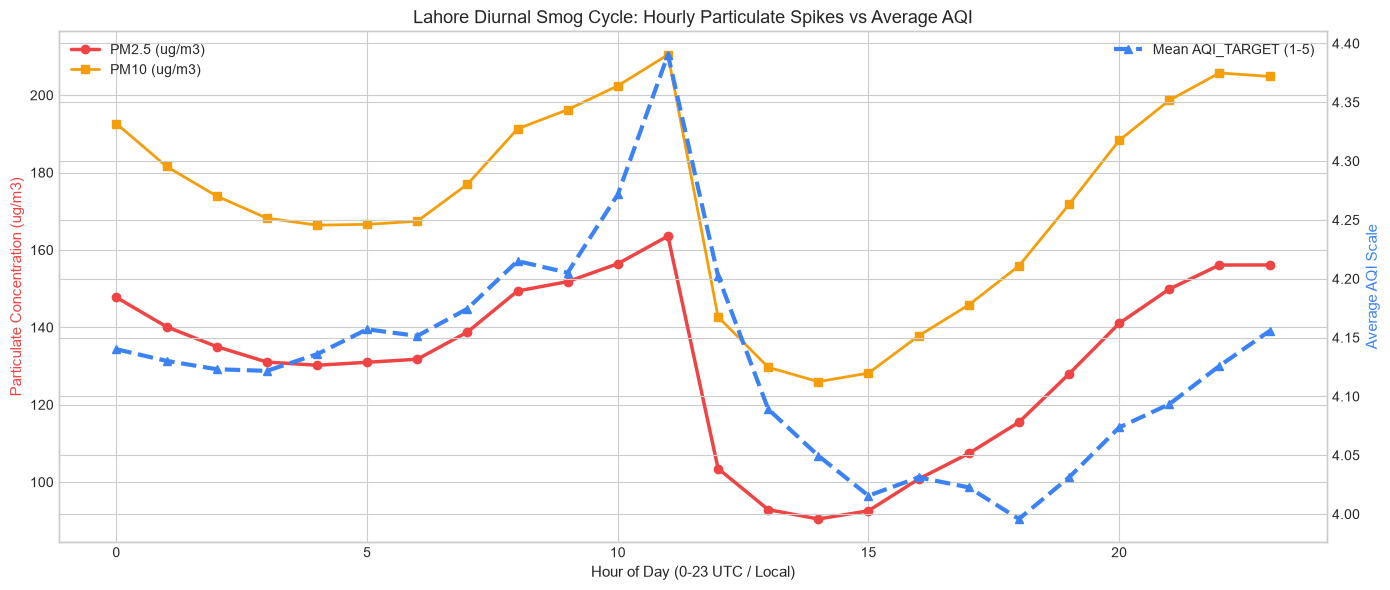

In [10]:
if 'hour' in df.columns and 'pm2_5' in df.columns:
    hourly_agg = df.groupby('hour')[[target_col, 'pm2_5', 'pm10', 'no2']].mean()
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()
    
    ax1.plot(hourly_agg.index, hourly_agg['pm2_5'], color='#ef4444', marker='o', label='PM2.5 (ug/m3)', linewidth=2.5)
    ax1.plot(hourly_agg.index, hourly_agg['pm10'], color='#f59e0b', marker='s', label='PM10 (ug/m3)', linewidth=2)
    ax2.plot(hourly_agg.index, hourly_agg[target_col], color='#3b82f6', marker='^', label=f'Mean {target_col.upper()} (1-5)', linewidth=3, linestyle='--')
    
    ax1.set_xlabel('Hour of Day (0-23 UTC / Local)', fontsize=11)
    ax1.set_ylabel('Particulate Concentration (ug/m3)', color='#ef4444', fontsize=11)
    ax2.set_ylabel('Average AQI Scale', color='#3b82f6', fontsize=11)
    ax1.set_title('Lahore Diurnal Smog Cycle: Hourly Particulate Spikes vs Average AQI', fontsize=13)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## 6. Seasonal & Monthly Trends (Winter Smog Episode Analysis)
Analyze winter smog intensification across October, November, December, and January.

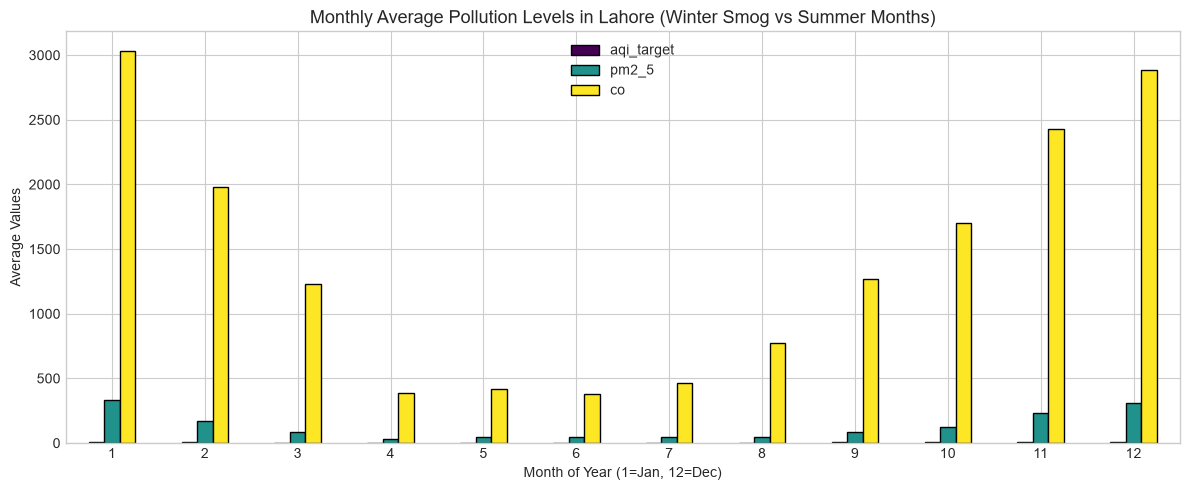

In [11]:
if 'month' in df.columns:
    monthly_agg = df.groupby('month')[[target_col, 'pm2_5', 'co']].mean()
    fig, ax = plt.subplots(figsize=(12, 5))
    monthly_agg.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title('Monthly Average Pollution Levels in Lahore (Winter Smog vs Summer Months)', fontsize=13)
    ax.set_xlabel('Month of Year (1=Jan, 12=Dec)')
    ax.set_ylabel('Average Values')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
